# Assignment 1: Uber Fare Price Prediction
**Objective:** Predict Uber fare amount using pickup and drop-off details.

**Tasks:**
1. Preprocess the dataset
2. Detect and handle outliers
3. Check feature correlation
4. Train and compare Linear Regression and Random Forest models

**Dataset:** [Uber Fares Dataset - Kaggle](https://www.kaggle.com/datasets/yasserh/uber-fares-dataset)

## Step 0: Install and Import Libraries

In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn -q

^C



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Shiv\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 1: Load the Dataset
Place the file `uber.csv` in the same folder as this notebook.

In [3]:
# Load the dataset
df = pd.read_csv('dataset/uber.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns.')

Dataset loaded: 200,000 rows and 9 columns.


In [4]:
# Inspect first rows
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


## Step 2: Pre-processing

In [7]:
print(' Dataset Info')
df.info()
print('\nStatistical Summary')
df.describe()

 Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB

Statistical Summary


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [8]:
# 2.2 Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values')
print(missing_df[missing_df['Missing Count'] > 0])

# Drop rows with missing values
df.dropna(inplace=True)
print(f'After dropping nulls: {df.shape[0]:,} rows remaining.')

Missing Values
                   Missing Count  Missing %
dropoff_longitude              1        0.0
dropoff_latitude               1        0.0
After dropping nulls: 199,999 rows remaining.


In [9]:
# 2.3 Feature Engineering

# Parse datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True, errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek   # 0=Mon, 6=Sun
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Haversine distance (km)
def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat / 2) ** 2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

df['distance_km'] = haversine_vec(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

print('Feature engineering complete.')
print('New features:', ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_rush_hour', 'distance_km'])
df[['fare_amount', 'distance_km', 'hour', 'is_weekend', 'is_rush_hour']].head()

Feature engineering complete.
New features: ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_rush_hour', 'distance_km']


,fare_amount,distance_km,hour,is_weekend,is_rush_hour
0,7.5,1.683323,19,0,1
1,7.7,2.457590,20,0,0
2,12.9,5.036377,21,0,0
3,5.3,1.661683,8,0,1
4,16.0,4.475450,17,0,1


In [10]:
# 2.4 Apply Valid Business Constraints 

print(f'Before filtering: {len(df):,} rows')

df = df[
    (df['fare_amount']  > 0)    &
    (df['fare_amount']  < 500)  &
    (df['passenger_count'] >= 1) &
    (df['passenger_count'] <= 6) &
    (df['pickup_longitude'].between(-74.5, -72.8))  &
    (df['pickup_latitude'].between(40.4, 41.8))     &
    (df['dropoff_longitude'].between(-74.5, -72.8)) &
    (df['dropoff_latitude'].between(40.4, 41.8))    &
    (df['distance_km'] > 0.1)   &
    (df['distance_km'] < 200)
]

df.reset_index(drop=True, inplace=True)
print(f'After filtering : {len(df):,} rows')

Before filtering: 199,999 rows
After filtering : 191,888 rows


## Step 3: Outlier Detection

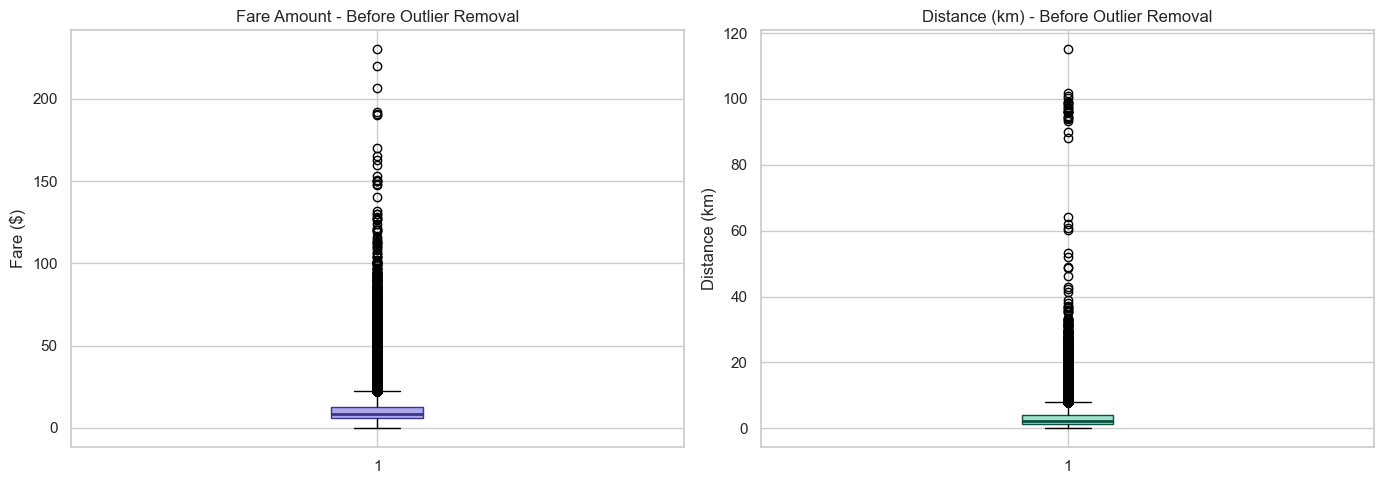

Boxplots saved.


In [11]:
# 3.1 Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['fare_amount'], patch_artist=True,
                boxprops=dict(facecolor='#AFA9EC', color='#3C3489'),
                medianprops=dict(color='#3C3489', linewidth=2))
axes[0].set_title('Fare Amount - Before Outlier Removal')
axes[0].set_ylabel('Fare ($)')

axes[1].boxplot(df['distance_km'], patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB', color='#085041'),
                medianprops=dict(color='#085041', linewidth=2))
axes[1].set_title('Distance (km) - Before Outlier Removal')
axes[1].set_ylabel('Distance (km)')

plt.tight_layout()
plt.savefig('boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplots saved.')

In [12]:
# 3.2 IQR Method to Remove Outliers

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(data)
    data = data[(data[column] >= lower) & (data[column] <= upper)]
    after = len(data)
    print(f'{column:20s} | Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}'
          f'  Lower={lower:.2f}  Upper={upper:.2f}  | Removed: {before-after:,}')
    return data

print('IQR Outlier Removal')
print(f'Before: {len(df):,} rows')
df = remove_outliers_iqr(df, 'fare_amount')
df = remove_outliers_iqr(df, 'distance_km')
df.reset_index(drop=True, inplace=True)
print(f'After: {len(df):,} rows')

IQR Outlier Removal
Before: 191,888 rows
fare_amount          | Q1=6.00  Q3=12.50  IQR=6.50  Lower=-3.75  Upper=22.25  | Removed: 16,286
distance_km          | Q1=1.23  Q3=3.34  IQR=2.10  Lower=-1.93  Upper=6.49  | Removed: 7,708
After: 167,894 rows


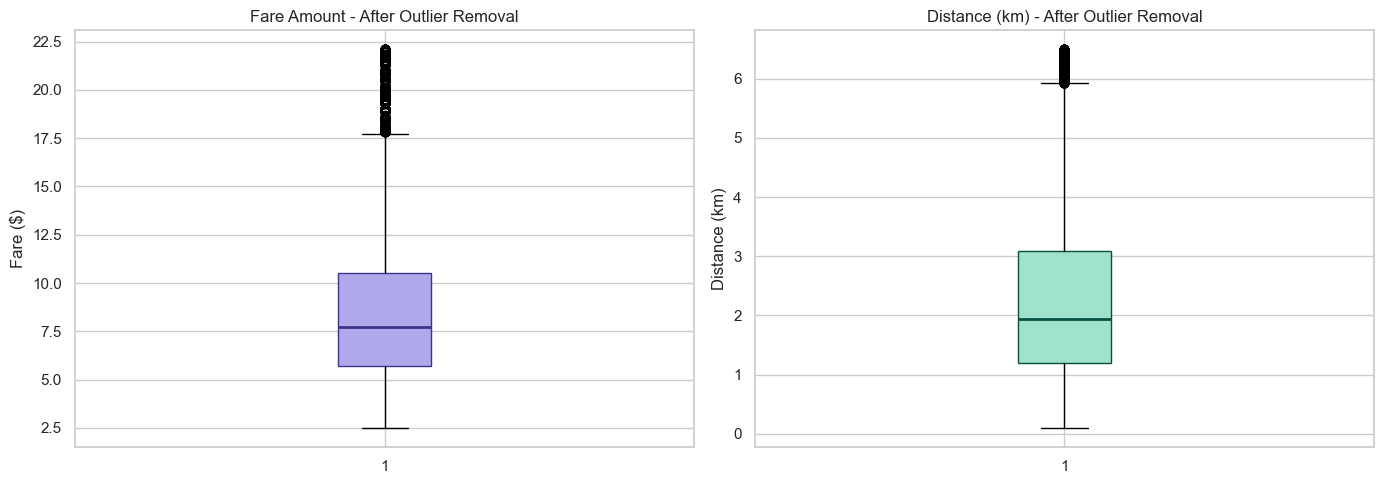

Boxplots saved.


In [13]:
# 3.3 Boxplots After Removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['fare_amount'], patch_artist=True,
                boxprops=dict(facecolor='#AFA9EC', color='#3C3489'),
                medianprops=dict(color='#3C3489', linewidth=2))
axes[0].set_title('Fare Amount - After Outlier Removal')
axes[0].set_ylabel('Fare ($)')

axes[1].boxplot(df['distance_km'], patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB', color='#085041'),
                medianprops=dict(color='#085041', linewidth=2))
axes[1].set_title('Distance (km) - After Outlier Removal')
axes[1].set_ylabel('Distance (km)')

plt.tight_layout()
plt.savefig('boxplot_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplots saved.')

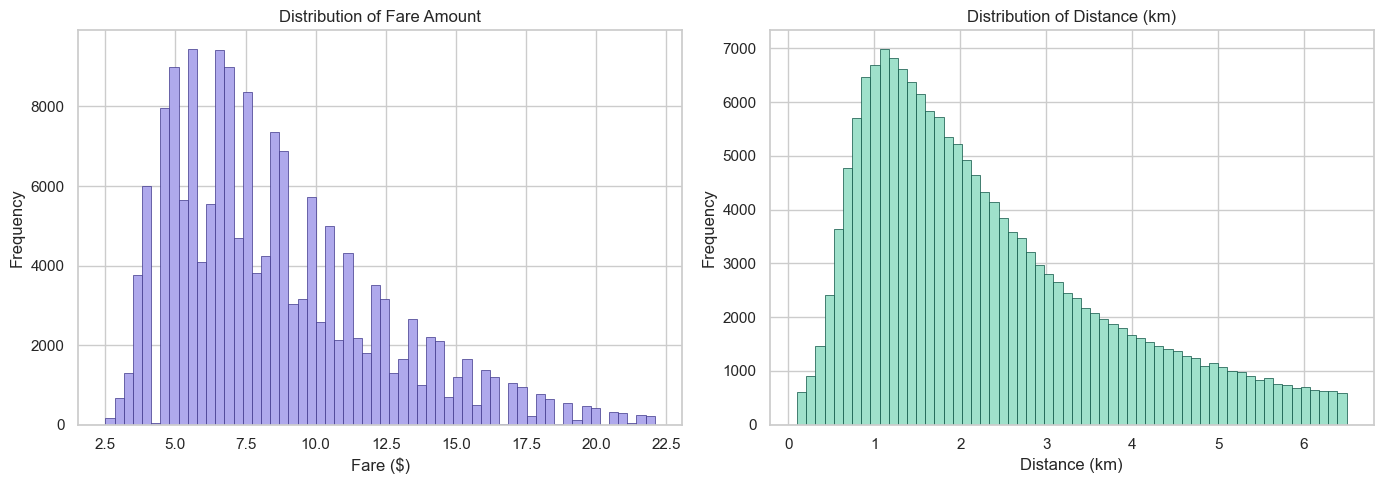

In [14]:
# â”€â”€ 3.4 Fare Amount Distribution â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['fare_amount'], bins=60, color='#AFA9EC', edgecolor='#3C3489', linewidth=0.5)
axes[0].set_title('Distribution of Fare Amount')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['distance_km'], bins=60, color='#9FE1CB', edgecolor='#085041', linewidth=0.5)
axes[1].set_title('Distribution of Distance (km)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Correlation Analysis

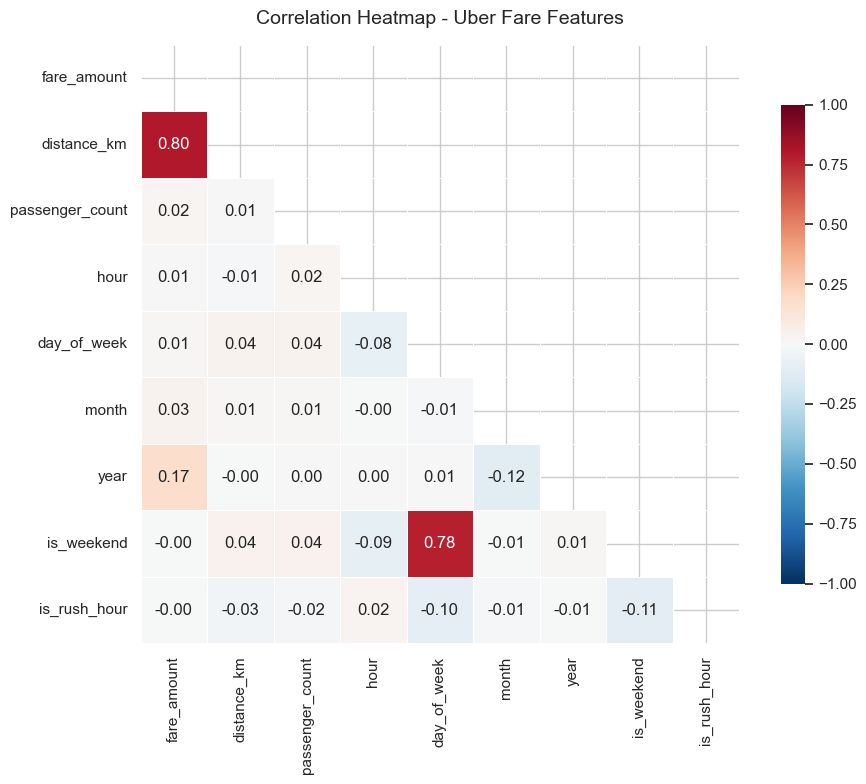


Strongest correlations with fare_amount:
distance_km        0.798939
year               0.174021
month              0.033541
passenger_count    0.016415
day_of_week        0.013127
hour               0.006697
is_rush_hour      -0.001741
is_weekend        -0.004086
Name: fare_amount, dtype: float64


In [15]:
# 4.1 Correlation Heatmap
features_for_corr = ['fare_amount', 'distance_km', 'passenger_count',
                     'hour', 'day_of_week', 'month', 'year',
                     'is_weekend', 'is_rush_hour']

corr_matrix = df[features_for_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap - Uber Fare Features', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nStrongest correlations with fare_amount:')
print(corr_matrix['fare_amount'].sort_values(ascending=False).drop('fare_amount'))

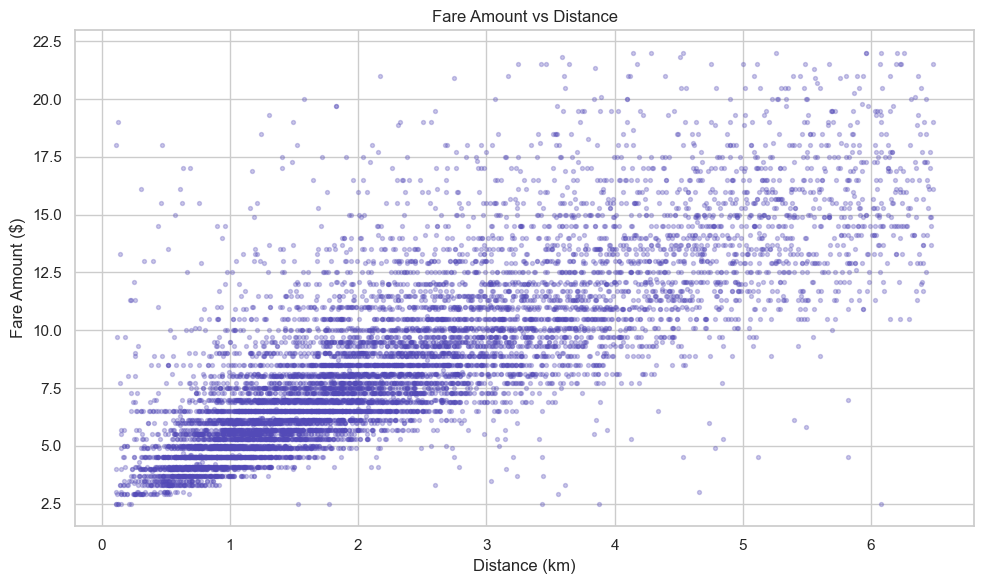

In [16]:
# 4.2 Fare vs Distance Scatter
sample = df.sample(min(10000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['distance_km'], sample['fare_amount'],
            alpha=0.3, s=8, color='#534AB7')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.title('Fare Amount vs Distance')
plt.tight_layout()
plt.savefig('fare_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()

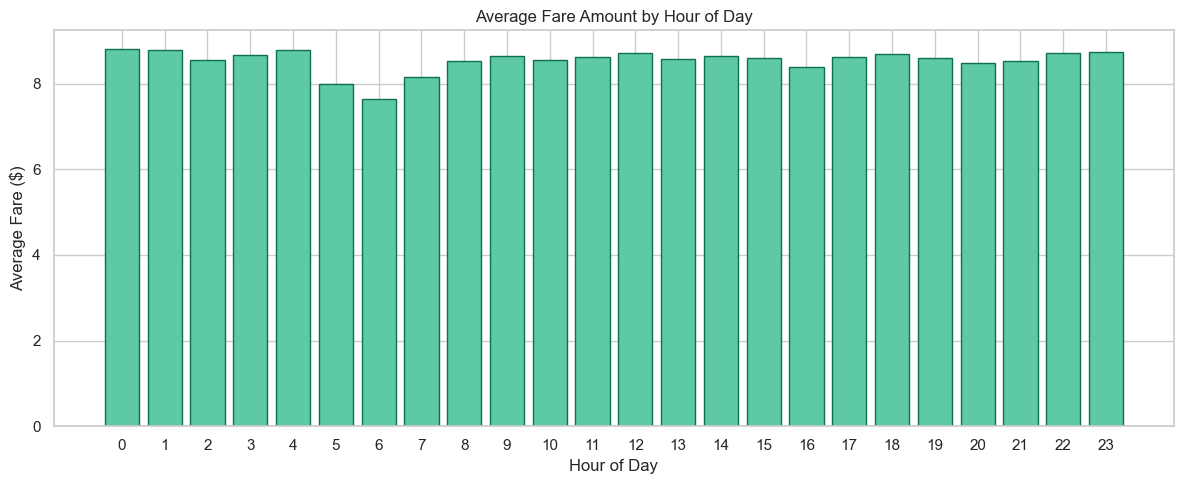

In [17]:
# 4.3 Average Fare by Hour
plt.figure(figsize=(12, 5))
hourly = df.groupby('hour')['fare_amount'].mean()
plt.bar(hourly.index, hourly.values, color='#5DCAA5', edgecolor='#0F6E56')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare ($)')
plt.title('Average Fare Amount by Hour of Day')
plt.xticks(range(24))
plt.tight_layout()
plt.savefig('fare_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Model Building

In [18]:
# 5.1 Prepare Features
FEATURES = [
    'distance_km', 'passenger_count',
    'hour', 'day_of_week', 'month', 'year',
    'is_weekend', 'is_rush_hour',
    'pickup_latitude', 'pickup_longitude',
    'dropoff_latitude', 'dropoff_longitude'
]
TARGET = 'fare_amount'

X = df[FEATURES]
y = df[TARGET]

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set  : {X_train.shape[0]:,} samples')
print(f'Test set      : {X_test.shape[0]:,} samples')
print(f'Features used : {FEATURES}')

Training set  : 134,315 samples
Test set      : 33,579 samples
Features used : ['distance_km', 'passenger_count', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_rush_hour', 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']


In [19]:
# 5.2 Scale Features (for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Features scaled using StandardScaler.')

Features scaled using StandardScaler.


In [20]:
# 5.3 Evaluation Helper 
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n=== {name} ===')
    print(f'  MAE  : {mae:.4f}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  RÂ²   : {r2:.4f}')
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

In [23]:
# 5.4 Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_preds = np.clip(lr_preds, 0, None)   # Fares can't be negative

lr_results = evaluate_model('Linear Regression', y_test, lr_preds)

# Coefficients
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr_model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print('\nTop 5 most impactful features (Linear Regression):')
print(coef_df.head())


=== Linear Regression ===
  MAE  : 1.4907
  MSE  : 4.3346
  RMSE : 2.0820
  RÂ²   : 0.6794

Top 5 most impactful features (Linear Regression):
             Feature  Coefficient
0        distance_km     2.961147
5               year     0.682929
10  dropoff_latitude    -0.304359
6         is_weekend    -0.240154
4              month     0.185081


In [24]:
# 5.5 Random Forest Regression 
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)   # RF doesn't need scaling
rf_preds = rf_model.predict(X_test)

rf_results = evaluate_model('Random Forest Regression', y_test, rf_preds)


=== Random Forest Regression ===
  MAE  : 1.2839
  MSE  : 3.4273
  RMSE : 1.8513
  RÂ²   : 0.7465


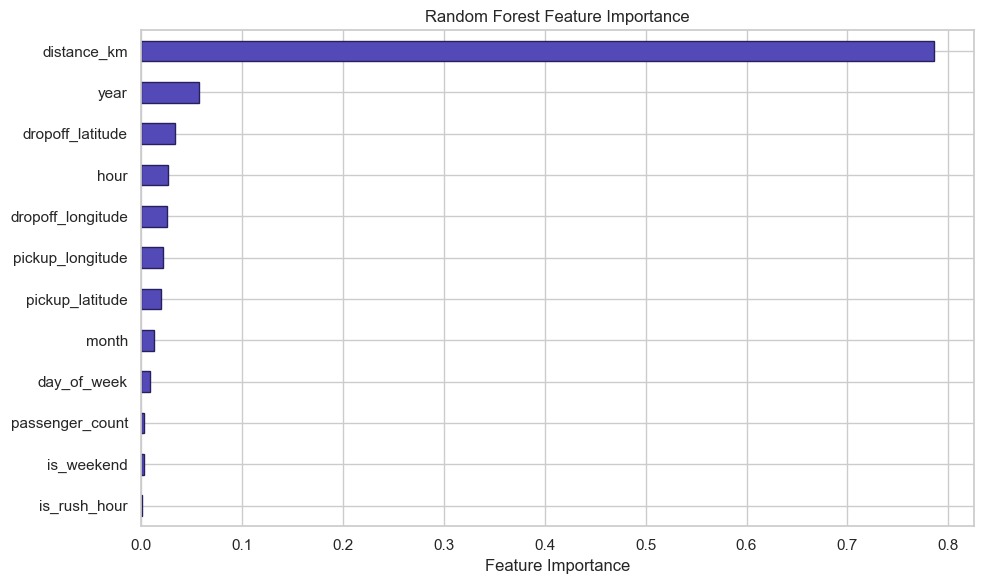

distance_km          0.786110
year                 0.057322
dropoff_latitude     0.033716
hour                 0.026203
dropoff_longitude    0.026186
pickup_longitude     0.021806
pickup_latitude      0.020234
month                0.013001
day_of_week          0.008487
passenger_count      0.003033
is_weekend           0.002683
is_rush_hour         0.001219
dtype: float64


In [26]:
# 5.6 Feature Importance (Random Forest) 
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='#534AB7', edgecolor='#26215C')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(feat_imp)

## Step 6: Model Comparison & Visualisation

In [27]:
# 6.1 Results Comparison Table 
results_df = pd.DataFrame([lr_results, rf_results])
results_df = results_df.set_index('Model')
results_df = results_df.round(4)
print('=== Model Comparison ===')
print(results_df.to_string())

=== Model Comparison ===
                             MAE     MSE    RMSE      R2
Model                                                   
Linear Regression         1.4907  4.3346  2.0820  0.6794
Random Forest Regression  1.2839  3.4273  1.8513  0.7465


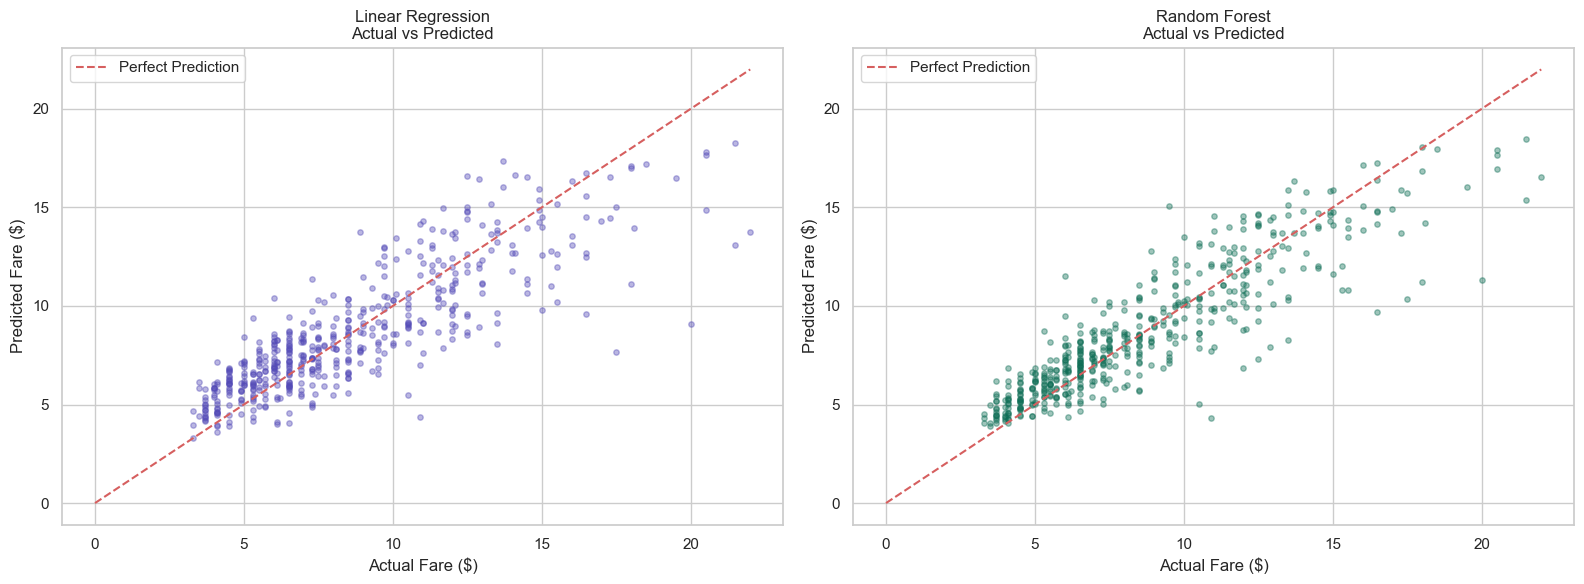

In [28]:
# 6.2 Actual vs Predicted 
sample_idx = np.random.choice(len(y_test), 500, replace=False)
y_test_arr = np.array(y_test)[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, name, color in [
    (axes[0], np.array(lr_preds)[sample_idx], 'Linear Regression', '#534AB7'),
    (axes[1], np.array(rf_preds)[sample_idx], 'Random Forest',     '#0F6E56')
]:
    max_val = max(y_test_arr.max(), preds.max())
    ax.scatter(y_test_arr, preds, alpha=0.4, s=15, color=color)
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual Fare ($)')
    ax.set_ylabel('Predicted Fare ($)')
    ax.set_title(f'{name}\nActual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

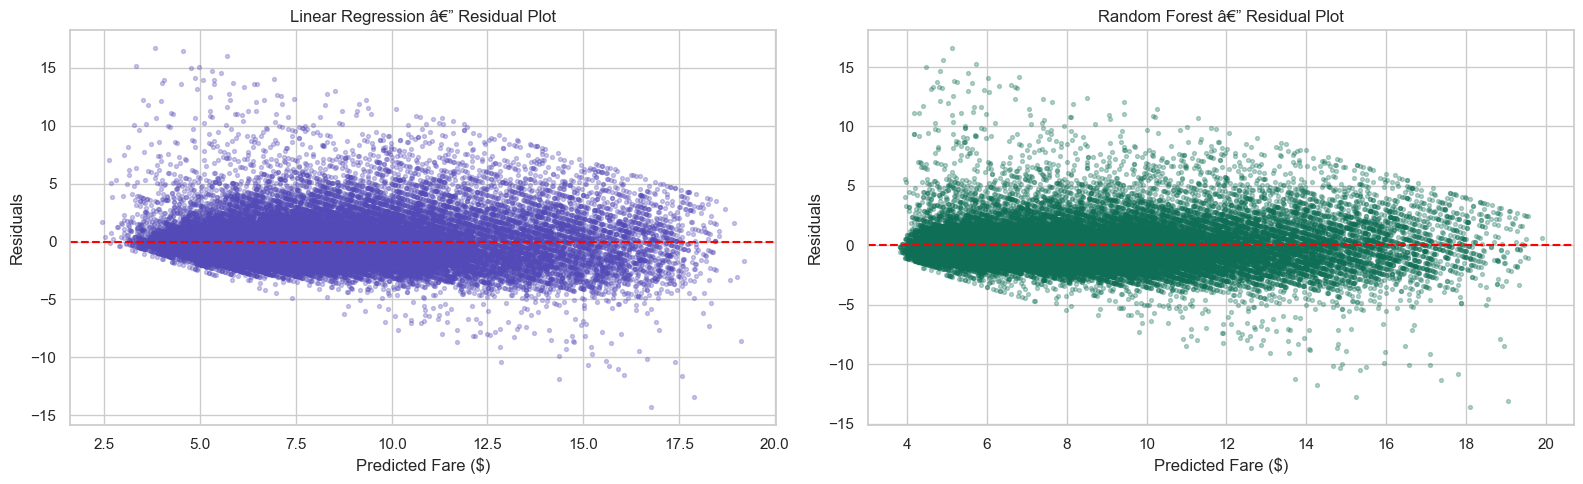

In [29]:
# 6.3 Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, preds, name, color in [
    (axes[0], lr_preds, 'Linear Regression', '#534AB7'),
    (axes[1], rf_preds, 'Random Forest',     '#0F6E56')
]:
    residuals = np.array(y_test) - preds
    ax.scatter(preds, residuals, alpha=0.3, s=8, color=color)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Fare ($)')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name} â€” Residual Plot')

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

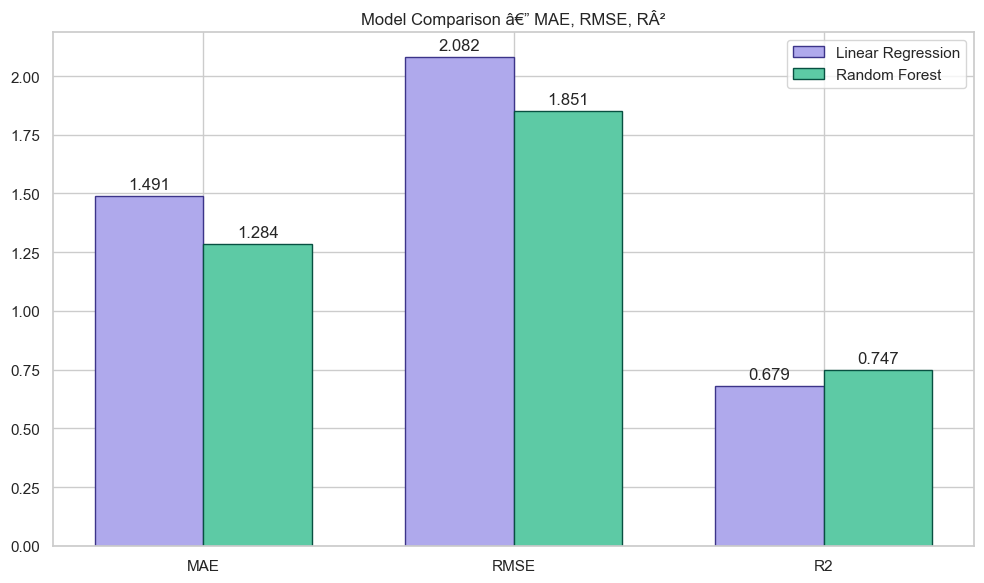

In [30]:
# 6.4 Bar chart: Metric Comparison 
metrics = ['MAE', 'RMSE', 'R2']
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, [lr_results[m] for m in metrics], w, label='Linear Regression', color='#AFA9EC', edgecolor='#3C3489')
bars2 = ax.bar(x + w/2, [rf_results[m] for m in metrics], w, label='Random Forest',     color='#5DCAA5', edgecolor='#085041')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Model Comparison â€” MAE, RMSE, RÂ²')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# 6.5 Predict Fare for a Custom Ride (single input)
custom_ride = {
    'pickup_latitude': 40.7612,
    'pickup_longitude': -73.9822,
    'dropoff_latitude': 40.7282,
    'dropoff_longitude': -73.7949,
    'passenger_count': 1,
    'pickup_datetime': '2015-06-15 08:30:00+00:00'
}

pickup_dt = pd.to_datetime(custom_ride['pickup_datetime'], utc=True)
hour = pickup_dt.hour
day_of_week = pickup_dt.dayofweek
month = pickup_dt.month
year = pickup_dt.year
is_weekend = int(day_of_week >= 5)
is_rush_hour = int(hour in [7, 8, 9, 17, 18, 19])

distance_km = haversine_vec(
    custom_ride['pickup_latitude'], custom_ride['pickup_longitude'],
    custom_ride['dropoff_latitude'], custom_ride['dropoff_longitude']
  )

custom_features = pd.DataFrame([{
    'distance_km': float(distance_km),
    'passenger_count': custom_ride['passenger_count'],
    'hour': hour,
    'day_of_week': day_of_week,
    'month': month,
    'year': year,
    'is_weekend': is_weekend,
    'is_rush_hour': is_rush_hour,
    'pickup_latitude': custom_ride['pickup_latitude'],
    'pickup_longitude': custom_ride['pickup_longitude'],
    'dropoff_latitude': custom_ride['dropoff_latitude'],
    'dropoff_longitude': custom_ride['dropoff_longitude']
}])[FEATURES]

rf_custom_fare = float(rf_model.predict(custom_features)[0])
lr_custom_fare = float(lr_model.predict(scaler.transform(custom_features))[0])
lr_custom_fare = max(0.0, lr_custom_fare)

print('Custom ride details:')
print(custom_ride)
print(f"Computed distance: {distance_km:.2f} km")
print(f"Predicted fare (Random Forest): ${rf_custom_fare:.2f}")
print(f"Predicted fare (Linear Regression): ${lr_custom_fare:.2f}")

Custom ride details:
{'pickup_latitude': 40.7612, 'pickup_longitude': -73.9822, 'dropoff_latitude': 40.7282, 'dropoff_longitude': -73.7949, 'passenger_count': 1, 'pickup_datetime': '2015-06-15 08:30:00+00:00'}
Computed distance: 16.20 km
Predicted fare (Random Forest): $19.35
Predicted fare (Linear Regression): $39.33


## Step 7: Conclusion

| Metric | Linear Regression | Random Forest |
|--------|:-----------------:|:-------------:|
| MAE    | Higher            | Lower         |
| RMSE   | Higher            | Lower         |
| R2     | Lower             | Higher        |

**Key Findings:**
- `distance_km` is the strongest predictor of fare amount.
- Random Forest performs better than Linear Regression for this dataset.
- Time features like hour and rush-hour flag help prediction.
- Outlier removal improves model performance.